In [ ]:
#Working

import re
import pdfplumber
from datetime import datetime, timedelta


#DOWS = {"Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"}


def parse_bid_range(page_text):
    m = re.search(
        r"Bid Period Date Range:\s*(\d{1,2}[A-Za-z]{3}\d{4})\s*-\s*(\d{1,2}[A-Za-z]{3}\d{4})",
        page_text,
    )
    if not m:
        raise ValueError("Could not find Bid Period Date Range")

    start = datetime.strptime(m.group(1), "%d%b%Y").date()
    end = datetime.strptime(m.group(2), "%d%b%Y").date()
    return start, end


def parse_domicile(page_text):
    m = re.search(r"Domicile:\s*([A-Z]{3})", page_text)
    if not m:
        raise ValueError("Could not find domicile")
    return m.group(1)


def words_on_same_line(words, top, tolerance=2.0):
    return [w for w in words if abs(w["top"] - top) <= tolerance]

def build_package_metadata(bid_start, bid_end):
    return {
        "bid_period_date_range": {
            "start": bid_start.isoformat(),
            "end": bid_end.isoformat(),
        },
        "pay_period_date_ranges": {
            "PP1": {
                "start": bid_start.isoformat(),
                "end": (bid_start + timedelta(days=27)).isoformat(),
            },
            "PP2": {
                "start": (bid_start + timedelta(days=28)).isoformat(),
                "end": (bid_start + timedelta(days=55)).isoformat(),
            },
        },
    }

PP_TOP_FROM_CT_OFFSET = 9.55


def find_pp_anchors(block_words):
    """
    Finds PP1 / PP2 sections using the CT: rows instead of the PP1/PP2 labels.

    This is more reliable because in VTO/VOR/RA/etc. pages,
    pdfplumber can merge hidden assignment text with the PP label.
    """
    ct_words = [
        w for w in block_words
        if w["text"] == "CT:"
        and 35 <= w["x0"] <= 100
    ]

    ct_words = sorted(ct_words, key=lambda w: w["top"])

    pp_anchors = []

    for i, ct_word in enumerate(ct_words[:2], start=1):
        pp_anchors.append({
            "pp_index": i,
            "top": ct_word["top"] - PP_TOP_FROM_CT_OFFSET,
        })

    return pp_anchors

def find_line_blocks(words, domicile):
    """
    Finds line blocks such as:
        SDF 1
        SDF 17
        SDF 18

    Returns y-ranges for each line block.
    """
    starts = []

    for w in words:
        if w["text"] == domicile and w["x0"] < 80 and w["top"] > 120:
            same_line = words_on_same_line(words, w["top"], tolerance=1.5)

            possible_numbers = [
                x for x in same_line
                if x["x0"] > w["x1"]
                and x["x0"] < 100
                and re.fullmatch(r"\d+", x["text"])
            ]

            if possible_numbers:
                starts.append({
                    "line_number": int(possible_numbers[0]["text"]),
                    "top": w["top"],
                })

    starts = sorted(starts, key=lambda x: x["top"])

    for i, block in enumerate(starts):
        if i + 1 < len(starts):
            block["bottom"] = starts[i + 1]["top"] - 5
        else:
            block["bottom"] = 99999

    return starts


def get_metric(words, pp_top, label):
    """
    Gets CT, BT, DO, DD from the left side of each PP row.
    """
    for w in words:
        if (
            w["text"] == label
            and w["x0"] < 90
            and pp_top <= w["top"] <= pp_top + 45
        ):
            same_line = sorted(
                words_on_same_line(words, w["top"], tolerance=1.5),
                key=lambda x: x["x0"],
            )

            after_label = [x for x in same_line if x["x0"] > w["x1"]]
            if after_label:
                return after_label[0]["text"]

    return None


def get_date_columns(words, pp_top):
    """
    The date numbers are on the line just above the PP label.
    We take only the first 28 date columns.

    Example:
        PP1: 21, 22, 23 ... 17
        PP2: 18, 19, 20 ... 15

    We ignore the extra '-- Mon 19' or '-- Mon 17' text after the 28-day grid.
    """
    date_words = [
        w for w in words
        if pp_top - 15 <= w["top"] <= pp_top - 5
        and re.fullmatch(r"\d{1,2}", w["text"])
        and w["x0"] > 80
    ]

    date_words = sorted(date_words, key=lambda w: w["x0"])
    return date_words[:28]

"""
def get_weekday_columns(words, pp_top):
    weekday_words = [
        w for w in words
        if pp_top - 28 <= w["top"] <= pp_top - 17
        and w["text"] in DOWS
        and w["x0"] > 80
    ]

    weekday_words = sorted(weekday_words, key=lambda w: w["x0"])
    return weekday_words[:28]
"""

def nearest_column_index(x, columns, max_distance=12.5):
    best_idx = None
    best_distance = None

    for i, col in enumerate(columns):
        distance = abs(col["center"] - x)

        if best_distance is None or distance < best_distance:
            best_idx = i
            best_distance = distance

    if best_distance is not None and best_distance <= max_distance:
        return best_idx

    return None


ASSIGNMENT_PATTERN = r"(?:\d+|VTO|VOR|RA|SA|RB|SB)"
TIME_PATTERN = r"(?:[01]\d|2[0-3])[0-5]\d"


TIME_PATTERN = r"(?:[01]\d|2[0-3])[0-5]\d"
ASSIGNMENT_PATTERN = r"(?:\d+|VTO|VOR|RA|SA|RB|SB)"


def word_center(w):
    return (w["x0"] + w["x1"]) / 2


def format_hhmm(token):
    return f"{token[:2]}:{token[2:]}"


def is_valid_time_token(token):
    if not re.fullmatch(r"\d{4}", token):
        return False

    hh = int(token[:2])
    mm = int(token[2:])

    return 0 <= hh <= 23 and 0 <= mm <= 59


def time_minutes(token):
    return int(token[:2]) * 60 + int(token[2:])

def nearest_date_boundary(x, columns):
    """
    Finds the nearest boundary between two adjacent date columns.

    Returns:
        {
            "left_index": i,
            "right_index": i + 1,
            "boundary_x": ...,
            "distance": ...
        }
    """

    best = None

    for i in range(len(columns) - 1):
        left_center = columns[i]["center"]
        right_center = columns[i + 1]["center"]

        boundary_x = (left_center + right_center) / 2
        distance = abs(x - boundary_x)

        if best is None or distance < best["distance"]:
            best = {
                "left_index": i,
                "right_index": i + 1,
                "boundary_x": boundary_x,
                "distance": distance,
            }

    return best 

def choose_trip_column_by_time(
    x,
    start_time_token,
    columns,
    fallback_index=None,
    boundary_tolerance=8,
    noon_cutoff_minutes=12 * 60,
):
    """
    Chooses the correct date column for a trip.

    Boundary case:
        If the trip number is printed near the boundary between two dates:
            1200-2359 -> left/previous date
            0000-1159 -> right/next date

    Normal case:
        Use nearest date column.

    Safety:
        If nearest_column_index() returns None, fall back to the original
        assignment column so the parser does not crash.
    """

    boundary = nearest_date_boundary(x, columns)

    if boundary is not None and boundary["distance"] <= boundary_tolerance:
        if start_time_token is not None and is_valid_time_token(start_time_token):
            if time_minutes(start_time_token) >= noon_cutoff_minutes:
                return boundary["left_index"]
            else:
                return boundary["right_index"]

    nearest_idx = nearest_column_index(x, columns)

    if nearest_idx is not None:
        return nearest_idx

    if fallback_index is not None:
        return fallback_index

    return None


def find_assignment_words(words, target_top, columns, y_tolerance=3):
    assignments = []

    min_center = min(col["center"] for col in columns) - 15
    max_center = max(col["center"] for col in columns) + 15

    for w in words:
        token = w["text"].strip().upper()

        if not re.fullmatch(ASSIGNMENT_PATTERN, token):
            continue

        if abs(w["top"] - target_top) > y_tolerance:
            continue

        x = word_center(w)

        if x < min_center or x > max_center:
            continue

        idx = nearest_column_index(x, columns)

        if idx is None:
            continue

        assignments.append({
            "token": token,
            "word": w,
            "column_index": idx,
        })

    assignments.sort(
        key=lambda item: (
            item["word"]["x0"],
            item["word"]["top"],
        )
    )

    return assignments


def find_start_time_for_trip(words, trip_word, x_tolerance=30, y_window=60):
    """
    Finds the start time associated with a numeric trip ID.

    Visual stack usually looks like:

        310
        RDU RDU RDU
        2310
        33:16

    So we prefer a valid HHMM time below the trip number.
    """

    trip_x = word_center(trip_word)

    candidates = []

    for w in words:
        token = w["text"].strip()

        if not is_valid_time_token(token):
            continue

        x_distance = abs(word_center(w) - trip_x)
        y_distance = abs(w["top"] - trip_word["top"])

        if x_distance > x_tolerance:
            continue

        if y_distance > y_window:
            continue

        is_below_trip = w["top"] > trip_word["top"]

        candidates.append({
            "word": w,
            "token": token,
            "x_distance": x_distance,
            "y_distance": y_distance,
            "is_below_trip": is_below_trip,
        })

    if not candidates:
        return None

    candidates.sort(
        key=lambda c: (
            0 if c["is_below_trip"] else 1,
            c["y_distance"],
            c["x_distance"],
        )
    )

    return candidates[0]

def parse_pp(words, pp_anchor, bid_start):
    pp_index = pp_anchor["pp_index"]
    pp_top = pp_anchor["top"]

    date_words = get_date_columns(words, pp_top)

    if len(date_words) < 28:
        raise ValueError(f"Only found {len(date_words)} date columns for PP{pp_index}")

    pp_start = bid_start + timedelta(days=28 * (pp_index - 1))

    columns = []

    for i, date_word in enumerate(date_words):
        actual_date = pp_start + timedelta(days=i)

        columns.append({
            "index": i,
            "date": actual_date.isoformat(),
            "center": word_center(date_word),
        })

    assignment_words = find_assignment_words(
        words=words,
        target_top=pp_top,
        columns=columns,
    )

    assignments = []

    for item in assignment_words:
        token = item["token"]
        assignment_word = item["word"]

        if token.isdigit():
            start_time_info = find_start_time_for_trip(
                words=words,
                trip_word=assignment_word,
            )

            start_time = None
            date_column_index = item["column_index"]

            if start_time_info is not None:
                start_time_token = start_time_info["token"]
                start_time_word = start_time_info["word"]

                start_time = format_hhmm(start_time_token)

                # Important:
                # Use the time to choose left/right date only when near a date boundary.
                date_column_index = choose_trip_column_by_time(
                            x=word_center(assignment_word),
                            start_time_token=start_time_token,
                            columns=columns,
                            fallback_index=item["column_index"],
                            boundary_tolerance=8,
                            )

            assignments.append({
                "date": columns[date_column_index]["date"],
                "start_time": start_time,
                "type": "trip",
                "value": int(token),
            })

        else:
            # VTO / VOR / RA / SA / RB / SB do not need time logic.
            assignments.append({
                "date": columns[item["column_index"]]["date"],
                "type": "code",
                "value": token,
            })

    return {
        "pp": f"PP{pp_index}",
        "CT": get_metric(words, pp_top, "CT:"),
        "BT": get_metric(words, pp_top, "BT:"),
        "DO": get_metric(words, pp_top, "DO:"),
        "DD": get_metric(words, pp_top, "DD:"),
        "assignments": assignments,
    }
    
def parse_line_report_page(page, bid_start, domicile):
    words = page.extract_words(
        x_tolerance=1,
        y_tolerance=2,
        keep_blank_chars=False
    )

    line_blocks = find_line_blocks(words, domicile)

    parsed_lines = []

    for line_block in line_blocks:
        block_words = [
            w for w in words
            if line_block["top"] - 5 <= w["top"] < line_block["bottom"]
        ]

        pp_anchors = find_pp_anchors(block_words)

        pp_data = []

        for pp_anchor in pp_anchors:
            pp_data.append(parse_pp(block_words, pp_anchor, bid_start))

        parsed_lines.append({
            "line_number": line_block["line_number"],
            "pay_periods": pp_data,
        })

    return parsed_lines


def parse_line_report_pdf(pdf_path, first_calendar_page=3):
    """
    first_calendar_page uses normal PDF page numbering.

    Example:
        first_calendar_page=5 means:
        skip pages 1-4, start extracting line calendar data on page 5.
    """

    first_calendar_index = first_calendar_page - 1

    with pdfplumber.open(pdf_path) as pdf:
        if first_calendar_index >= len(pdf.pages):
            raise ValueError(
                f"first_calendar_page={first_calendar_page} is beyond the end of the PDF. "
                f"The PDF only has {len(pdf.pages)} pages."
            )

        # Read metadata from the first actual calendar page, not PDF page 1.
        metadata_text = pdf.pages[first_calendar_index].extract_text(
            x_tolerance=1,
            y_tolerance=2
        ) or ""

        bid_start, bid_end = parse_bid_range(metadata_text)
        domicile = parse_domicile(metadata_text)

        result = build_package_metadata(bid_start, bid_end)
        result["lines"] = []

        for page in pdf.pages[first_calendar_index:]:
            page_lines = parse_line_report_page(
                page=page,
                bid_start=bid_start,
                domicile=domicile,
            )
            result["lines"].extend(page_lines)

    return result

In [9]:
from pprint import pprint

pdf_path = "/home/aleluc/Github_repos/UPS-project/SamplePDFs/2304 Lines.pdf"

lines = parse_line_report_pdf(pdf_path, first_calendar_page=3)

pprint(lines, width=160)

{'bid_period_date_range': {'end': '2023-07-16', 'start': '2023-05-21'},
 'lines': [{'line_number': 1,
            'pay_periods': [{'BT': '52:48',
                             'CT': '72:00',
                             'DD': '12',
                             'DO': '11',
                             'assignments': [{'date': '2023-05-23', 'start_time': '06:51', 'type': 'trip', 'value': 7},
                                             {'date': '2023-05-24', 'start_time': '06:51', 'type': 'trip', 'value': 7},
                                             {'date': '2023-05-25', 'start_time': '06:58', 'type': 'trip', 'value': 14},
                                             {'date': '2023-05-31', 'start_time': '06:51', 'type': 'trip', 'value': 8},
                                             {'date': '2023-06-01', 'start_time': '06:51', 'type': 'trip', 'value': 8},
                                             {'date': '2023-06-06', 'start_time': '06:51', 'type': 'trip', 'value': 8},
       

In [35]:
import re
import pdfplumber
from datetime import timedelta
from IPython.display import display
import pandas as pd


def visualize_current_pp_columns(
    pdf_path,
    pdf_page_number,
    line_number,
    pp="PP1",
    row_y_tolerance=3,
    candidate_y_tolerance=10,
    resolution=150,
):
    """
    Notebook visualizer for the CURRENT column detection logic.

    This does NOT require add_column_boundaries().
    It draws:
        blue vertical lines  = detected date column centers
        purple horizontal   = detected PP assignment row
        black horizontals   = detected line block top/bottom
        orange boxes        = assignment words close to the PP row

    It also prints a DataFrame showing where tokens like 395, 310, VTO, etc.
    are being seen by pdfplumber.
    """

    pp_index = int(pp.replace("PP", ""))

    with pdfplumber.open(pdf_path) as pdf:
        first_page_text = pdf.pages[0].extract_text(x_tolerance=1, y_tolerance=2) or ""
        bid_start, bid_end = parse_bid_range(first_page_text)
        domicile = parse_domicile(first_page_text)

        page = pdf.pages[pdf_page_number - 1]

        words = page.extract_words(
            x_tolerance=1,
            y_tolerance=2,
            keep_blank_chars=False,
        )

        line_blocks = find_line_blocks(words, domicile)

        selected_line = None
        for line_block in line_blocks:
            if line_block["line_number"] == line_number:
                selected_line = line_block
                break

        if selected_line is None:
            raise ValueError(f"Could not find line {line_number} on page {pdf_page_number}")

        block_words = [
            w for w in words
            if selected_line["top"] - 5 <= w["top"] < selected_line["bottom"]
        ]

        pp_anchors = find_pp_anchors(block_words)

        selected_pp_anchor = None
        for anchor in pp_anchors:
            if anchor["pp_index"] == pp_index:
                selected_pp_anchor = anchor
                break

        if selected_pp_anchor is None:
            raise ValueError(f"Could not find {pp} for line {line_number}")

        pp_top = selected_pp_anchor["top"]

        date_words = get_date_columns(block_words, pp_top)

        if len(date_words) < 28:
            print(f"WARNING: only found {len(date_words)} date columns")

        pp_start = bid_start + timedelta(days=28 * (pp_index - 1))

        columns = []

        for i, date_word in enumerate(date_words[:28]):
            actual_date = pp_start + timedelta(days=i)

            columns.append({
                "index": i,
                "date": actual_date.isoformat(),
                "date_word": date_word["text"],
                "center": (date_word["x0"] + date_word["x1"]) / 2,
                "x0": date_word["x0"],
                "x1": date_word["x1"],
            })

        def nearest_debug(x):
            best_idx = None
            best_distance = None

            for i, col in enumerate(columns):
                distance = abs(col["center"] - x)

                if best_distance is None or distance < best_distance:
                    best_idx = i
                    best_distance = distance

            return best_idx, best_distance

        # Draw image directly in notebook
        im = page.to_image(resolution=resolution)

        # Line block boundaries
        im.draw_hline(selected_line["top"], stroke="black", stroke_width=2)
        im.draw_hline(selected_line["bottom"], stroke="black", stroke_width=2)

        # PP assignment row
        im.draw_hline(pp_top, stroke="purple", stroke_width=2)

        # Detected date column centers
        for col in columns:
            im.draw_vline(col["center"], stroke="blue", stroke_width=1)

        token_rows = []

        for w in sorted(block_words, key=lambda x: (x["top"], x["x0"])):
            token = w["text"].strip().upper()

            if not re.fullmatch(ASSIGNMENT_PATTERN, token):
                continue

            y_distance = abs(w["top"] - pp_top)

            # Show possible nearby candidates, even if your parser would reject them.
            if y_distance > candidate_y_tolerance:
                continue

            word_center = (w["x0"] + w["x1"]) / 2
            nearest_idx, nearest_distance = nearest_debug(word_center)

            would_be_used_by_parser = y_distance <= row_y_tolerance

            token_rows.append({
                "token": token,
                "x0": round(w["x0"], 2),
                "x1": round(w["x1"], 2),
                "center": round(word_center, 2),
                "top": round(w["top"], 2),
                "pp_top": round(pp_top, 2),
                "y_distance": round(y_distance, 2),
                "would_pass_y_tolerance": would_be_used_by_parser,
                "nearest_column_index": nearest_idx,
                "nearest_column_date": columns[nearest_idx]["date"] if nearest_idx is not None else None,
                "nearest_distance": round(nearest_distance, 2) if nearest_distance is not None else None,
            })

            # Orange box around all nearby candidates
            im.draw_rect(w, stroke="orange", stroke_width=2)

        display(im.annotated)

        print(f"PDF page: {pdf_page_number}")
        print(f"Line: {line_number}")
        print(f"PP: {pp}")
        print(f"Detected pp_top: {pp_top:.2f}")
        print(f"Detected date columns: {len(columns)}")
        print()

        columns_df = pd.DataFrame(columns)
        tokens_df = pd.DataFrame(token_rows)

        display(columns_df)
        display(tokens_df)

        return {
            "page": page,
            "line_block": selected_line,
            "pp_top": pp_top,
            "columns": columns,
            "tokens": token_rows,
        }

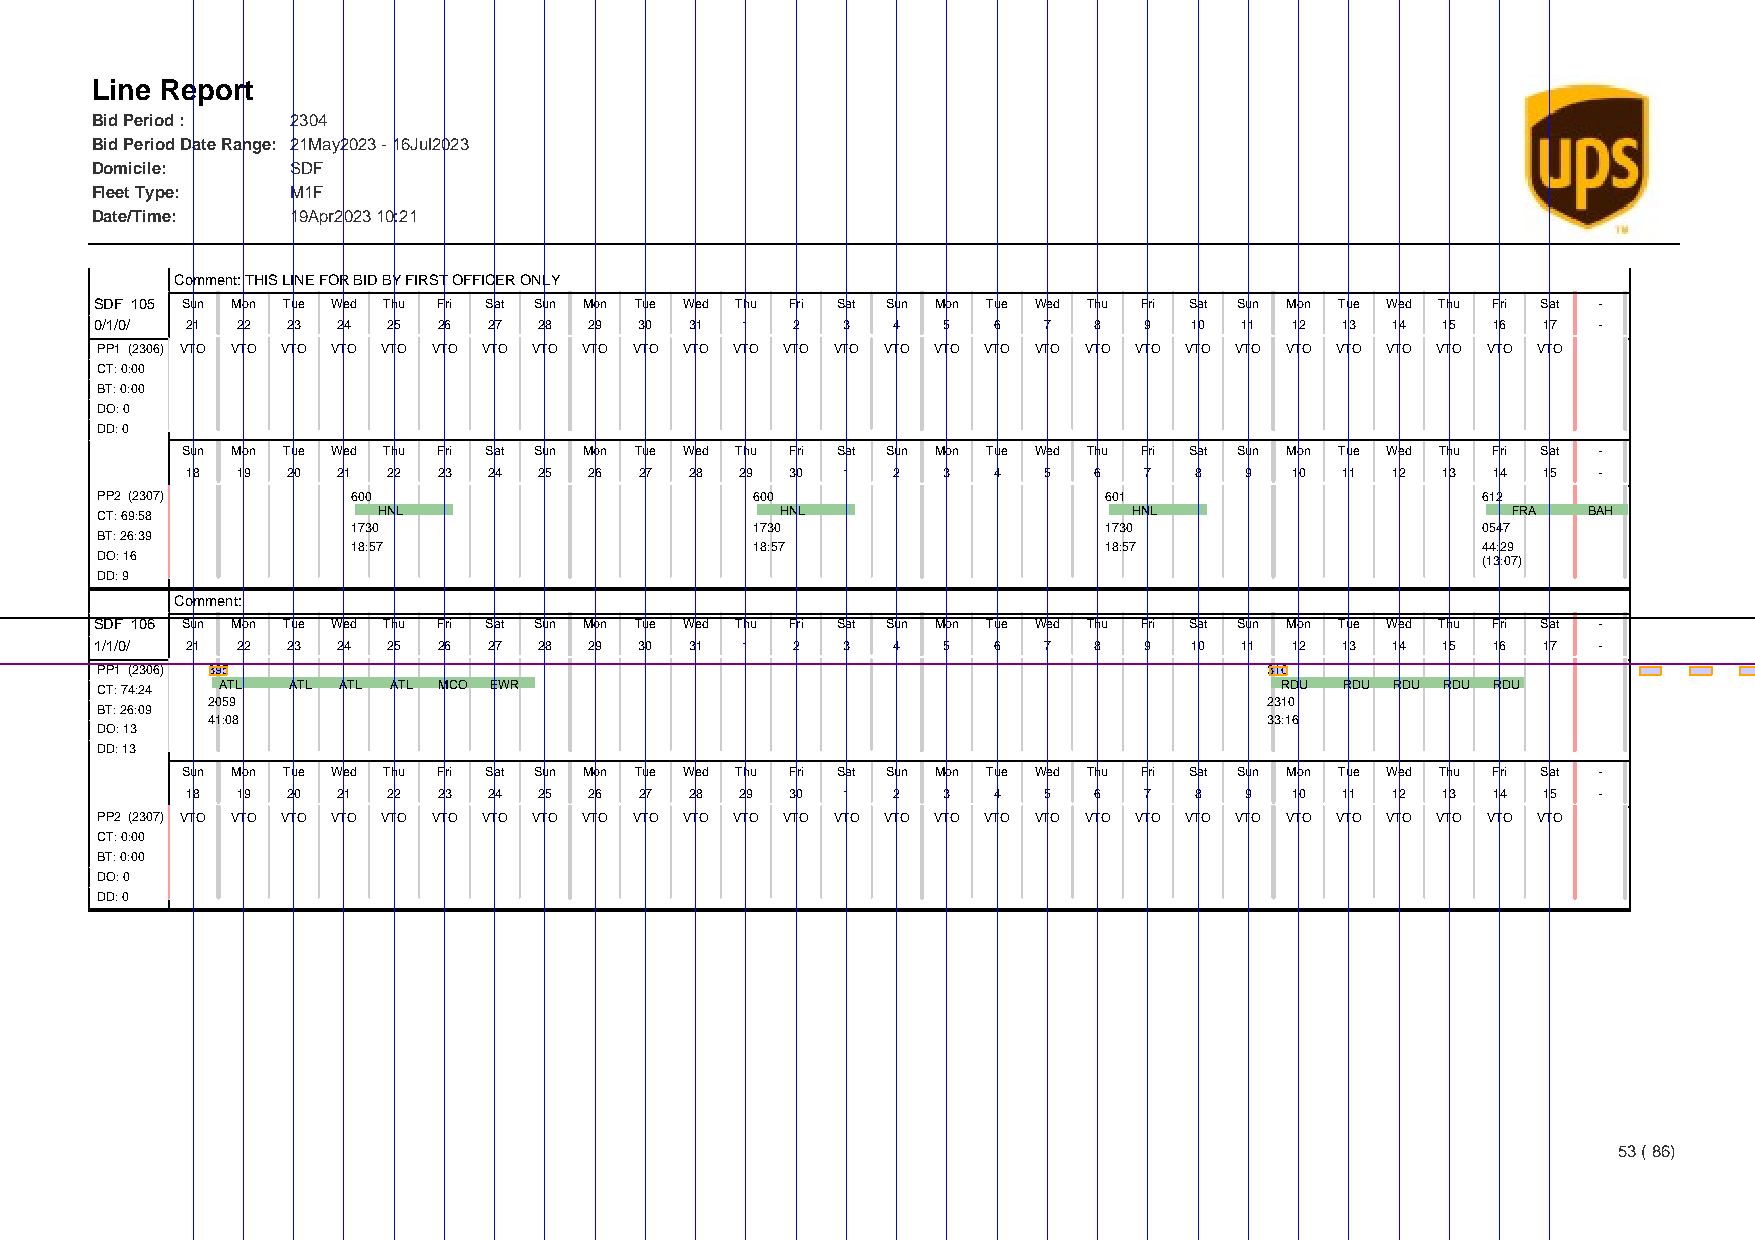

PDF page: 3
Line: 106
PP: PP1
Detected pp_top: 318.55
Detected date columns: 28



,index,date,date_word,center,x0,x1
0,0,2023-05-21,21,92.7188,89.3828,96.0548
1,1,2023-05-22,22,116.8438,113.5078,120.1798
2,2,2023-05-23,23,140.9375,137.6015,144.2735
3,3,2023-05-24,24,165.0313,161.6953,168.3673
4,4,2023-05-25,25,189.1563,185.8203,192.4923
5,5,2023-05-26,26,213.2500,209.9140,216.5860
6,6,2023-05-27,27,237.3438,234.0078,240.6798
7,7,2023-05-28,28,261.4375,258.1015,264.7735
8,8,2023-05-29,29,285.5625,282.2265,288.8985
9,9,2023-05-30,30,309.6563,306.3203,312.9923


,token,x0,x1,center,top,pp_top,y_distance,would_pass_y_tolerance,nearest_column_index,nearest_column_date,nearest_distance
0,395,99.75,109.76,104.75,318.79,318.55,0.24,True,0,2023-05-21,12.04
1,310,608.09,618.10,613.10,318.79,318.55,0.24,True,22,2023-06-12,9.90
2,VTO,785.55,797.89,791.72,318.79,318.55,0.24,True,27,2023-06-17,48.19
3,VTO,809.68,822.01,815.84,318.79,318.55,0.24,True,27,2023-06-17,72.31
4,VTO,833.77,846.11,839.94,318.79,318.55,0.24,True,27,2023-06-17,96.41
5,VTO,857.86,870.20,864.03,318.79,318.55,0.24,True,27,2023-06-17,120.50
6,VTO,881.99,894.32,888.16,318.79,318.55,0.24,True,27,2023-06-17,144.62
7,VTO,906.08,918.42,912.25,318.79,318.55,0.24,True,27,2023-06-17,168.72
8,VTO,930.18,942.51,936.34,318.79,318.55,0.24,True,27,2023-06-17,192.81
9,VTO,954.27,966.61,960.44,318.79,318.55,0.24,True,27,2023-06-17,216.91


In [39]:
debug = visualize_current_pp_columns(
    pdf_path="/home/aleluc/Github_repos/UPS-project/SamplePDFs/2304 Lines edge case.pdf",
    pdf_page_number=3,
    line_number=106,
    pp="PP1",
)

In [1]:
import re
from typing import Any
import pdfplumber


TIME_RE = r"\(\d{2}\)\d{2}:\d{2}"
DUR_RE = r"\d+h\d{2}"

DUTY_START_RE = re.compile(
    rf"^(?P<duty_start>{TIME_RE})\s+"
    rf"(?P<show_time>{DUR_RE})\s+"
    rf"Duty\s+(?P<duty_time>{DUR_RE})"
)

DUTY_END_RE = re.compile(
    rf"^(?P<duty_end>{TIME_RE})\s+0h15(?:\s+(?P<summary>.*))?$"
)

ROUTE_RE = re.compile(
    r"(?P<route>[A-Z]{3}(?:\([A-Z]\))?(?:-(?:IRO|[A-Z]{3}(?:\([A-Z]\))?))+)"
)

FLIGHT_HEAD_RE = re.compile(
    r"^(?P<trip_day>\d+)\s+"
    r"(?P<ops_day>\([^)]*\)[A-Za-z]{0,2})\s+"
    r"(?P<body>.+)$"
)

FLIGHT_TIMES_RE = re.compile(
    rf"^(?P<start>{TIME_RE})\s+"
    rf"(?P<end>{TIME_RE})\s+"
    rf"(?P<leg_block>{DUR_RE})"
    rf"(?:\s+(?P<tail>.*))?$"
)

BLOCK_RE = re.compile(r"Block\s+(?P<block>\d+h\d{2})")
REST_RE = re.compile(r"Rest\s+(?P<rest>-|\d+h\d{2})(?:\s+(?P<rest_code>S\d+))?")
CREDIT_RE = re.compile(r"Credit\s+(?P<credit>\d+h\d{2}[A-Z]?)")


def group_words_by_line(words: list[dict[str, Any]], tolerance: float = 2.0):
    """
    Groups pdfplumber words into visual text lines.
    This helps find the real Trip Id positions on the page.
    """
    lines = []

    for word in sorted(words, key=lambda w: (w["top"], w["x0"])):
        placed = False

        for line in lines:
            if abs(line[0]["top"] - word["top"]) <= tolerance:
                line.append(word)
                placed = True
                break

        if not placed:
            lines.append([word])

    return [sorted(line, key=lambda w: w["x0"]) for line in lines]


def find_trip_anchors(page):
    """
    Finds each 'Trip Id: ###' position on the page.
    This is important because the page may contain several trip tables.
    """
    words = page.extract_words(x_tolerance=1, y_tolerance=3) or []
    anchors = []

    for line in group_words_by_line(words):
        texts = [w["text"] for w in line]

        for i in range(len(texts) - 2):
            if texts[i] == "Trip" and texts[i + 1] == "Id:" and texts[i + 2].isdigit():
                anchors.append(
                    {
                        "trip_id": int(texts[i + 2]),
                        "x0": line[i]["x0"],
                        "top": line[i]["top"],
                    }
                )

    return sorted(anchors, key=lambda a: (a["top"], a["x0"]))


def make_trip_bboxes(page):
    """
    Creates a crop box around each trip table.

    This step is necessary because the PDF page has left/right tables.
    If you extract the whole page at once, text from different tables can mix.
    """
    anchors = find_trip_anchors(page)

    if not anchors:
        return []

    page_middle = page.width / 2

    for anchor in anchors:
        anchor["column"] = 0 if anchor["x0"] < page_middle else 1

    boxes = []

    for anchor in anchors:
        same_column_below = [
            other
            for other in anchors
            if other["column"] == anchor["column"]
            and other["top"] > anchor["top"] + 5
        ]

        bottom = min(
            [other["top"] for other in same_column_below],
            default=page.height - 18,
        )

        if anchor["column"] == 0:
            x0 = 0
            x1 = page_middle - 2
        else:
            x0 = page_middle + 2
            x1 = page.width

        boxes.append(
            {
                "trip_id": anchor["trip_id"],
                "bbox": (
                    x0,
                    max(0, anchor["top"] - 3),
                    x1,
                    min(page.height, bottom - 2),
                ),
            }
        )

    return boxes


def parse_route(route_raw: str):
    """
    Parses routes like:
        SDF-PHL
        SDF-BDL(C)
        SDF-IRO-PHL

    IRO is kept as route_flag, but not treated as the destination.
    """
    parts = route_raw.split("-")

    real_airports = []
    route_flags = []

    for part in parts:
        if part == "IRO":
            route_flags.append("IRO")
        else:
            real_airports.append(part)

    departure_raw = real_airports[0] if real_airports else None
    arrival_raw = real_airports[-1] if real_airports else None

    def clean_airport(value):
        if value is None:
            return None, None

        match = re.match(r"^([A-Z]{3})(?:\(([^)]+)\))?$", value)

        if not match:
            return value, None

        airport = match.group(1)
        note = match.group(2)

        return airport, note

    departure, departure_note = clean_airport(departure_raw)
    arrival, arrival_note = clean_airport(arrival_raw)

    return {
        "route_raw": route_raw,
        "departure": departure,
        "arrival": arrival,
        "departure_note": departure_note,
        "arrival_note": arrival_note,
        "route_flag": ",".join(route_flags) if route_flags else None,
    }


def parse_flight_line(line: str):
    """
    Parses one flight/deadhead/bus line inside a duty block.
    """
    head_match = FLIGHT_HEAD_RE.match(line)

    if not head_match:
        return None

    body = head_match.group("body")

    route_match = ROUTE_RE.search(body)

    if not route_match:
        return None

    flight = body[: route_match.start()].strip()
    route_raw = route_match.group("route")
    after_route = body[route_match.end() :].strip()

    time_match = FLIGHT_TIMES_RE.match(after_route)

    if not time_match:
        return None

    flight_data = {
        "trip_day": int(head_match.group("trip_day")),
        "ops_day": head_match.group("ops_day"),
        "flight": flight,
        "start": time_match.group("start"),
        "end": time_match.group("end"),
        "leg_block": time_match.group("leg_block"),
        "extra_text": (time_match.group("tail") or "").strip(),
    }

    flight_data.update(parse_route(route_raw))

    return flight_data


def get_first_match(pattern: str, text: str, default=None):
    match = re.search(pattern, text)

    if not match:
        return default

    return match.group(1)


def parse_trip_text(text: str):
    """
    Parses the text from one cropped trip table.
    Returns one nested dictionary.
    """
    lines = [line.strip() for line in text.splitlines() if line.strip()]
    full_text = "\n".join(lines)

    trip_id = int(get_first_match(r"Trip Id:\s*(\d+)", full_text))

    lines_text = get_first_match(r"Lines:\s*([^\n]+)", full_text, "")
    line_numbers = [int(x) for x in re.findall(r"\d+", lines_text)]

    trip = {
        "trip_id": trip_id,
        "lines": line_numbers,
        "tafb": get_first_match(r"TAFB:\s*(\d+h\d{2})", full_text),
        "premium": float(get_first_match(r"Premium\s+([\d.]+)", full_text, 0)),
        "trip_block_time": get_first_match(r"Block Time:\s*(\d+h\d{2})", full_text),
        "credit_time": get_first_match(r"Credit Time:\s*(\d+h\d{2}[A-Z]?)", full_text),
        "blocks": [],
    }

    current_block = None

    for line in lines:
        duty_start_match = DUTY_START_RE.match(line)

        if duty_start_match:
            current_block = {
                "block_no": len(trip["blocks"]) + 1,
                "duty_start": duty_start_match.group("duty_start"),
                "show_time": duty_start_match.group("show_time"),
                "duty_time": duty_start_match.group("duty_time"),
                "duty_end": None,
                "duty_block_time": None,
                "rest_after": None,
                "rest_code": None,
                "credit": None,
                "flights": [],
            }

            trip["blocks"].append(current_block)
            continue

        if current_block is None:
            continue

        flight = parse_flight_line(line)

        if flight:
            current_block["flights"].append(flight)

        duty_end_match = DUTY_END_RE.match(line)

        if duty_end_match:
            current_block["duty_end"] = duty_end_match.group("duty_end")

        block_match = BLOCK_RE.search(line)
        rest_match = REST_RE.search(line)
        credit_match = CREDIT_RE.search(line)

        if block_match:
            current_block["duty_block_time"] = block_match.group("block")

        if rest_match:
            current_block["rest_after"] = rest_match.group("rest")
            current_block["rest_code"] = rest_match.group("rest_code")

        if credit_match:
            current_block["credit"] = credit_match.group("credit")

    trip["num_duty_blocks"] = len(trip["blocks"])
    trip["num_legs"] = sum(len(block["flights"]) for block in trip["blocks"])

    return trip


def extract_trips_from_pdf(pdf_path, first_page=1, last_page=None):
    """
    Extracts all trips from a trip-package PDF.

    Page numbers are 1-based:
        first_page=2 means PDF page 2.
        last_page=4 means PDF page 4.

    Returns:
        dict keyed by trip_id.
    """
    trips = {}

    with pdfplumber.open(pdf_path) as pdf:
        start_index = first_page - 1

        if last_page is None:
            end_index = len(pdf.pages)
        else:
            end_index = last_page

        for page_index in range(start_index, end_index):
            page = pdf.pages[page_index]

            for item in make_trip_bboxes(page):
                cropped_page = page.crop(item["bbox"])
                text = cropped_page.extract_text(x_tolerance=1, y_tolerance=3) or ""

                if "Trip Id:" not in text:
                    continue

                trip = parse_trip_text(text)
                trip["page"] = page_index + 1

                trips[trip["trip_id"]] = trip

    return trips

In [5]:
from pprint import pprint

pdf_path = "/home/aleluc/Github_repos/UPS-project/SamplePDFs/2304 2 lines and trips.pdf"

trips = extract_trips_from_pdf(pdf_path,first_page=2,last_page=4)

pprint(trips)

{96: {'blocks': [{'block_no': 1,
                  'credit': '4h13D',
                  'duty_block_time': '3h19',
                  'duty_end': '(00)04:09',
                  'duty_start': '(15)19:43',
                  'duty_time': '8h26',
                  'flights': [{'arrival': 'PHL',
                               'arrival_note': None,
                               'departure': 'SDF',
                               'departure_note': None,
                               'end': '(18)22:23',
                               'extra_text': 'M1F 3h52 1/1 Block 3h19 '
                                             'Domicile: SDF',
                               'flight': '2198',
                               'leg_block': '1h40',
                               'ops_day': '(Mo)Mo',
                               'route_flag': None,
                               'route_raw': 'SDF-PHL',
                               'start': '(16)20:43',
                               'trip_day': 1},
      

In [ ]:
#Working
import re
import pdfplumber


TIME_RE = r"\(\d{2}\)\d{2}:\d{2}"
DUR_RE = r"\d+h\d{2}"


def group_words_by_line(words, tolerance=2):
    lines = []

    for word in sorted(words, key=lambda w: (w["top"], w["x0"])):
        for line in lines:
            if abs(line[0]["top"] - word["top"]) <= tolerance:
                line.append(word)
                break
        else:
            lines.append([word])

    return [sorted(line, key=lambda w: w["x0"]) for line in lines]


def find_trip_anchors(page):
    """
    Finds each 'Trip Id: ###' on the page.
    Needed because each page can contain several trip tables.
    """
    words = page.extract_words(x_tolerance=1, y_tolerance=3) or []
    anchors = []

    for line in group_words_by_line(words):
        text_parts = [w["text"] for w in line]

        for i in range(len(text_parts) - 2):
            if (
                text_parts[i] == "Trip"
                and text_parts[i + 1] == "Id:"
                and text_parts[i + 2].isdigit()
            ):
                anchors.append({
                    "trip_id": int(text_parts[i + 2]),
                    "x0": line[i]["x0"],
                    "top": line[i]["top"],
                })

    return sorted(anchors, key=lambda a: (a["top"], a["x0"]))


def make_trip_crops(page):
    """
    Builds a crop box for each trip table.

    The crop is necessary because the PDF pages can have left/right tables.
    Without cropping, pdfplumber may mix text from different tables.
    """
    anchors = find_trip_anchors(page)
    page_middle = page.width / 2

    for anchor in anchors:
        anchor["column"] = 0 if anchor["x0"] < page_middle else 1

    crops = []

    for anchor in anchors:
        next_trip_same_column = [
            other
            for other in anchors
            if other["column"] == anchor["column"]
            and other["top"] > anchor["top"] + 5
        ]

        bottom = min(
            [other["top"] for other in next_trip_same_column],
            default=page.height - 10,
        )

        if anchor["column"] == 0:
            x0, x1 = 0, page_middle - 2
        else:
            x0, x1 = page_middle + 2, page.width

        crops.append((
            x0,
            max(0, anchor["top"] - 3),
            x1,
            min(page.height, bottom - 2),
        ))

    return crops


def split_route(route_raw):
    """
    Example:
        SDF-PHL         -> departure SDF, arrival PHL, route_flags []
        SDF-IRO-PHL     -> departure SDF, arrival PHL, route_flags ['IRO']
        SDF-BDL(C)      -> departure SDF, arrival BDL(C), route_flags []
    """
    parts = route_raw.split("-")

    airports = []
    route_flags = []

    for part in parts:
        if part == "IRO":
            route_flags.append(part)
        else:
            airports.append(part)

    departure = airports[0] if airports else None
    arrival = airports[-1] if airports else None

    return departure, arrival, route_flags


def parse_flight_line(line):
    """
    Extracts only:
    - flight
    - route_raw
    - departure
    - arrival
    - route_flags, such as IRO
    - start
    - end
    """

    # Removes the beginning like:
    # 1 (Mo)Mo
    # 2 ( ) 
    match = re.match(r"^\d+\s+\([^)]*\)[A-Za-z]{0,2}\s+(.*)$", line)

    if not match:
        return None

    body = match.group(1)

    route_match = re.search(
        r"[A-Z]{3}(?:\([A-Z]\))?(?:-(?:IRO|[A-Z]{3}(?:\([A-Z]\))?))+",
        body,
    )

    if not route_match:
        return None

    flight = body[:route_match.start()].strip()
    route_raw = route_match.group(0)
    after_route = body[route_match.end():].strip()

    time_match = re.match(
        rf"(?P<start>{TIME_RE})\s+(?P<end>{TIME_RE})",
        after_route,
    )

    if not time_match:
        return None

    departure, arrival, route_flags = split_route(route_raw)

    return {
        "flight": flight,
        "route_raw": route_raw,
        "departure": departure,
        "arrival": arrival,
        "route_flags": route_flags,
        "start": time_match.group("start"),
        "end": time_match.group("end"),
    }


def parse_trip_text(text):
    """
    Parses one trip table into a dictionary.
    """

    lines = [line.strip() for line in text.splitlines() if line.strip()]
    full_text = "\n".join(lines)

    trip_id = int(re.search(r"Trip Id:\s*(\d+)", full_text).group(1))

    lines_match = re.search(r"Lines:\s*([^\n]+)", full_text)
    line_numbers = []

    if lines_match:
        line_numbers = [int(x) for x in re.findall(r"\d+", lines_match.group(1))]

    tafb_match = re.search(r"TAFB:\s*(\d+h\d{2})", full_text)
    premium_match = re.search(r"Premium\s+([\d.]+)", full_text)

    trip = {
        "trip_id": trip_id,
        "lines": line_numbers,
        "total_blocks": 0,
        "tafb": tafb_match.group(1) if tafb_match else None,
        "premium": float(premium_match.group(1)) if premium_match else None,
        "blocks": [],
    }

    current_block = None

    for line in lines:
        # A new duty block starts each time we see:
        # (20)00:20 1h00 Duty 7h00
        duty_match = re.match(
            rf"^{TIME_RE}\s+{DUR_RE}\s+Duty\s+{DUR_RE}",
            line,
        )

        if duty_match:
            current_block = {
                "flights": [],
                "rest": None,
            }
            trip["blocks"].append(current_block)
            continue

        if current_block is None:
            continue

        flight = parse_flight_line(line)

        if flight:
            current_block["flights"].append(flight)

        rest_match = re.search(r"Rest\s+(-|\d+h\d{2})", line)

        if rest_match:
            current_block["rest"] = rest_match.group(1)

    trip["total_blocks"] = len(trip["blocks"])

    return trip


def extract_trips_from_pdf(pdf_path, first_page=2, last_page=None):
    """
    Returns a dictionary keyed by Trip ID.

    Page numbers are normal PDF page numbers:
        first_page=2 means page 2.
        last_page=4 means page 4.
    """

    trips = {}

    with pdfplumber.open(pdf_path) as pdf:
        start_index = first_page - 1
        end_index = last_page if last_page is not None else len(pdf.pages)

        for page_index in range(start_index, end_index):
            page = pdf.pages[page_index]

            for bbox in make_trip_crops(page):
                cropped = page.crop(bbox)
                text = cropped.extract_text(x_tolerance=1, y_tolerance=3) or ""

                if "Trip Id:" not in text:
                    continue

                trip = parse_trip_text(text)
                trips[trip["trip_id"]] = trip

    return trips

In [ ]:
#Working
import re
import pdfplumber


TIME_RE = r"\(\d{2}\)\d{2}:\d{2}"
DUR_RE = r"\d+h\d{2}"

def clean_time(value):
    """
    Converts:
        (16)20:43 -> 20:43
        (00)04:09 -> 04:09
    """
    if value is None:
        return None

    return re.sub(r"^\(\d{2}\)", "", value)


def group_words_by_line(words, tolerance=2):
    lines = []

    for word in sorted(words, key=lambda w: (w["top"], w["x0"])):
        for line in lines:
            if abs(line[0]["top"] - word["top"]) <= tolerance:
                line.append(word)
                break
        else:
            lines.append([word])

    return [sorted(line, key=lambda w: w["x0"]) for line in lines]


def find_trip_anchors(page):
    """
    Finds each 'Trip Id: ###' on the page.
    Needed because each page can contain several trip tables.
    """
    words = page.extract_words(x_tolerance=1, y_tolerance=3) or []
    anchors = []

    for line in group_words_by_line(words):
        text_parts = [w["text"] for w in line]

        for i in range(len(text_parts) - 2):
            if (
                text_parts[i] == "Trip"
                and text_parts[i + 1] == "Id:"
                and text_parts[i + 2].isdigit()
            ):
                anchors.append({
                    "trip_id": int(text_parts[i + 2]),
                    "x0": line[i]["x0"],
                    "top": line[i]["top"],
                })

    return sorted(anchors, key=lambda a: (a["top"], a["x0"]))


def make_trip_crops(page):
    """
    Builds a crop box for each trip table.

    The crop is necessary because the PDF pages can have left/right tables.
    Without cropping, pdfplumber may mix text from different tables.
    """
    anchors = find_trip_anchors(page)
    page_middle = page.width / 2

    for anchor in anchors:
        anchor["column"] = 0 if anchor["x0"] < page_middle else 1

    crops = []

    for anchor in anchors:
        next_trip_same_column = [
            other
            for other in anchors
            if other["column"] == anchor["column"]
            and other["top"] > anchor["top"] + 5
        ]

        bottom = min(
            [other["top"] for other in next_trip_same_column],
            default=page.height - 10,
        )

        if anchor["column"] == 0:
            x0, x1 = 0, page_middle - 2
        else:
            x0, x1 = page_middle + 2, page.width

        crops.append((
            x0,
            max(0, anchor["top"] - 3),
            x1,
            min(page.height, bottom - 2),
        ))

    return crops


def split_route(route_raw):
    """
    Examples:
        SDF-PHL         -> departure SDF, arrival PHL, route_flags []
        SDF-IRO-PHL     -> departure SDF, arrival PHL, route_flags ['IRO']
        SDF-BDL(C)      -> departure SDF, arrival BDL, route_flags ['C']
        SDF-IRO-BDL(C)  -> departure SDF, arrival BDL, route_flags ['IRO', 'C']
    """
    parts = route_raw.split("-")

    airports = []
    route_flags = []

    for part in parts:
        if part == "IRO":
            route_flags.append("IRO")
            continue

        # Handles airport with parenthetical flag, like BDL(C)
        match = re.match(r"^([A-Z]{3})(?:\(([A-Z]+)\))?$", part)

        if match:
            airport = match.group(1)
            flag = match.group(2)

            airports.append(airport)

            if flag:
                route_flags.append(flag)
        else:
            airports.append(part)

    departure = airports[0] if airports else None
    arrival = airports[-1] if airports else None

    return departure, arrival, route_flags


def parse_flight_line(line):
    """
    Extracts only:
    - flight
    - route_raw
    - departure
    - arrival
    - route_flags, such as IRO
    - start
    - end
    """

    match = re.match(r"^\d+\s+\([^)]*\)[A-Za-z]{0,2}\s+(.*)$", line)

    if not match:
        return None

    body = match.group(1)

    route_match = re.search(
        r"[A-Z]{3}(?:\([A-Z]\))?(?:-(?:IRO|[A-Z]{3}(?:\([A-Z]\))?))+",
        body,
    )

    if not route_match:
        return None

    flight = body[:route_match.start()].strip()
    route_raw = route_match.group(0)
    after_route = body[route_match.end():].strip()

    time_match = re.match(
        rf"(?P<start>{TIME_RE})\s+(?P<end>{TIME_RE})",
        after_route,
    )

    if not time_match:
        return None

    departure, arrival, route_flags = split_route(route_raw)

    return {
        "flight": flight,
        "route_raw": route_raw,
        "departure": departure,
        "arrival": arrival,
        "route_flags": route_flags,
        "start": clean_time(time_match.group("start")),
        "end": clean_time(time_match.group("end")),
    }


def parse_trip_text(text):
    """
    Parses one trip table into a dictionary.
    """

    lines = [line.strip() for line in text.splitlines() if line.strip()]
    full_text = "\n".join(lines)

    trip_id = int(re.search(r"Trip Id:\s*(\d+)", full_text).group(1))

    lines_match = re.search(r"Lines:\s*([^\n]+)", full_text)
    line_numbers = []

    if lines_match:
        line_numbers = [int(x) for x in re.findall(r"\d+", lines_match.group(1))]

    tafb_match = re.search(r"TAFB:\s*(\d+h\d{2})", full_text)
    premium_match = re.search(r"Premium\s+([\d.]+)", full_text)

    trip = {
        "trip_id": trip_id,
        "lines": line_numbers,
        "total_blocks": 0,
        "tafb": tafb_match.group(1) if tafb_match else None,
        "premium": float(premium_match.group(1)) if premium_match else None,
        "blocks": [],
    }

    current_block = None

    for line in lines:
        # New block starts with something like:
        # (15)19:43 1h00 Duty 8h26
        duty_match = re.match(
            rf"^(?P<block_start>{TIME_RE})\s+{DUR_RE}\s+Duty\s+{DUR_RE}",
            line,
        )

        if duty_match:
            current_block = {
                "start": clean_time(duty_match.group("block_start")),
                "end": None,
                "rest": None,
                "flights": [],
            }
            trip["blocks"].append(current_block)
            continue

        if current_block is None:
            continue

        # Block ends with something like:
        # (00)04:09 0h15 Credit 4h13D
        block_end_match = re.match(
            rf"^(?P<block_end>{TIME_RE})\s+0h15",
            line,
        )

        if block_end_match:
            current_block["end"] = clean_time(block_end_match.group("block_end"))

        flight = parse_flight_line(line)

        if flight:
            # For the first flight in each block, use the block/duty start time,
            # not the actual flight departure time.
            if not current_block["flights"]:
                flight["start"] = current_block["start"]

            current_block["flights"].append(flight)

        rest_match = re.search(r"Rest\s+(-|\d+h\d{2})", line)

        if rest_match:
            current_block["rest"] = rest_match.group(1)

    trip["total_blocks"] = len(trip["blocks"])

    return trip


def extract_trips_from_pdf(pdf_path, first_page=2, last_page=None):
    """
    Returns a dictionary keyed by Trip ID.

    Page numbers are normal PDF page numbers:
        first_page=2 means page 2.
        last_page=4 means page 4.
    """

    trips = {}

    with pdfplumber.open(pdf_path) as pdf:
        start_index = first_page - 1
        end_index = last_page if last_page is not None else len(pdf.pages)

        for page_index in range(start_index, end_index):
            page = pdf.pages[page_index]

            for bbox in make_trip_crops(page):
                cropped = page.crop(bbox)
                text = cropped.extract_text(x_tolerance=1, y_tolerance=3) or ""

                if "Trip Id:" not in text:
                    continue

                trip = parse_trip_text(text)
                trips[trip["trip_id"]] = trip

    return trips

In [14]:
from pprint import pprint

pdf_path = "/home/aleluc/Github_repos/UPS-project/SamplePDFs/2304 Trips.pdf"

trips = extract_trips_from_pdf(pdf_path,first_page=2)

pprint(trips)

{1: {'blocks': [{'end': '14:10',
                 'flights': [{'arrival': 'JFK',
                              'departure': 'SDF',
                              'end': '08:55',
                              'flight': '1114',
                              'route_flags': [],
                              'route_raw': 'SDF-JFK',
                              'start': '06:13'},
                             {'arrival': 'SDF',
                              'departure': 'JFK',
                              'end': '13:55',
                              'flight': '2111',
                              'route_flags': [],
                              'route_raw': 'JFK-SDF',
                              'start': '11:55'}],
                 'rest': '-',
                 'start': '06:13'}],
     'lines': [3],
     'premium': 0.0,
     'tafb': '7h57',
     'total_blocks': 1,
     'trip_id': 1},
 2: {'blocks': [{'end': '14:10',
                 'flights': [{'arrival': 'JFK',
                         